# Noise-Aware Variational Quantum Machine Learning for Tabular Anomaly Detection

This notebook implements a noise-aware hybrid quantum-classical framework for anomaly detection on the UNSW-NB15 network intrusion dataset. Rather than assuming perfectly stable feature embeddings, our approach incorporates stochastic perturbations at the classical-to-quantum interface and jointly optimizes a noise-regularized variational quantum classifier. This design improves robustness to input uncertainty and instability in hybrid quantum pipelines while retaining efficient pure-state simulation. The experiments contained herein demonstrate that this noise-aware training strategy enhances ranking performance and robustness compared to non-regularized quantum baselines on real-world tabular network traffic data.

## 1. Environment Setup

In [ ]:
!pip install pennylane torch scikit-learn pandas numpy kaggle

## 2. Upload Kaggle API Key

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (2).json


{'kaggle (2).json': b'{"username":"sakshamgarg7167","key":"e93ba948509c012e3d6764cdd1c7bf25"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

## 3. Download UNSW-NB15 Dataset

In [ ]:
!rm -rf unsw-nb15.zip UNSW_NB15_*.csv
!kaggle datasets download -d mrwellsdavid/unsw-nb15
!unzip -o unsw-nb15.zip

Dataset URL: https://www.kaggle.com/datasets/mrwellsdavid/unsw-nb15
License(s): unknown
 70% 105M/149M [00:00<00:00, 1.10GB/s]
100% 149M/149M [00:00<00:00, 475MB/s] 
Archive:  unsw-nb15.zip
  inflating: NUSW-NB15_features.csv  
  inflating: UNSW-NB15_1.csv         
  inflating: UNSW-NB15_2.csv         
  inflating: UNSW-NB15_3.csv         
  inflating: UNSW-NB15_4.csv         
  inflating: UNSW-NB15_LIST_EVENTS.csv  
  inflating: UNSW_NB15_testing-set.csv  
  inflating: UNSW_NB15_training-set.csv  


## 4. Global Configuration

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import (roc_auc_score, f1_score, precision_recall_curve,
                             confusion_matrix, roc_curve, auc, average_precision_score,
                             precision_score, recall_score, accuracy_score)
from sklearn.decomposition import PCA
from tqdm import tqdm
from math import pi

TRAIN_SUBSAMPLE = 3000
TEST_SUBSAMPLE  = 2000
N_FEATURES = 8

class ModelEvaluator:
    @staticmethod
    def compute_optimal_threshold(y_true, scores):
        #Finds threshold maximizing F1-score.
        if len(np.unique(y_true)) < 2: return 0.5
        precision, recall, thresholds = precision_recall_curve(y_true, scores)
        numerator = 2 * precision * recall
        denominator = precision + recall
        f1_scores = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator!=0)
        best_idx = np.argmax(f1_scores[:-1])
        return thresholds[best_idx], f1_scores[best_idx]

    @staticmethod
    def get_confidence(scores, threshold):
        # Standardized definition: Distance from the decision boundary.
        return np.abs(scores - threshold)

evaluator = ModelEvaluator()

def evaluate(Y, scores, threshold):
    # Standard evaluation dictionary used by all models.
    preds = (scores > threshold).astype(int)
    return {
        "ROC-AUC": roc_auc_score(Y, scores),
        "Average Precision": average_precision_score(Y, scores),
        "F1": f1_score(Y, preds, zero_division=0)
    }

class TrainingLogger:
    def __init__(self):
        self.history = {"epoch": [], "total_loss": [], "cls_loss": [],
                        "noise_loss": [], "noise_param": [], "train_auc": [], "train_f1": []}

    def log(self, epoch, total_loss, cls_loss, noise_loss, noise_param, train_auc=None, train_f1=None):
        self.history["epoch"].append(epoch)
        self.history["total_loss"].append(total_loss)
        self.history["cls_loss"].append(cls_loss)
        self.history["noise_loss"].append(noise_loss)
        self.history["noise_param"].append(noise_param)
        self.history["train_auc"].append(train_auc)
        self.history["train_f1"].append(train_f1)

def train_with_logging(model, X, Y, epochs=20, lam=0.1):
    # Train model with noise-aware regularization and logging.
    model.train()
    opt = torch.optim.AdamW(
        model.parameters(),
        lr=0.01,
        weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=10, T_mult=2, eta_min=1e-6)
    logger = TrainingLogger()

    X_t = torch.tensor(X, dtype=torch.float32)
    Y_t = torch.tensor(Y, dtype=torch.float32)

    # Class weighting
    n_pos = Y_t.sum().item()
    n_neg = len(Y_t) - n_pos
    pos_weight = torch.tensor([n_neg / n_pos if n_pos > 0 else 1.0])

    for e in tqdm(range(epochs), desc="Training"):
        opt.zero_grad()
        logits = model(X_t).squeeze()
        loss_cls = F.binary_cross_entropy_with_logits(logits, Y_t, pos_weight=pos_weight)

        # Adaptive regularization
        loss_noise = noise_penalty(model, X_t)
        loss = loss_cls + (lam * (1 - e/epochs)**0.5 * loss_noise)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        scheduler.step(e)

        # Logging (Dynamic Thresholding)
        if (e + 1) % 5 == 0:
            with torch.no_grad():
                scores = torch.sigmoid(logits).numpy()
                y_np = Y_t.numpy()
                auc_score = roc_auc_score(y_np, scores)
                thr, _ = evaluator.compute_optimal_threshold(y_np, scores)
                f1 = f1_score(y_np, scores > thr, zero_division=0)
                logger.log(e, loss.item(), loss_cls.item(), loss_noise.item(),
                           model.input_noise_scale.item(), auc_score, f1)
        else:
            logger.log(e, loss.item(), loss_cls.item(), loss_noise.item(), model.input_noise_scale.item())

    return logger

In [ ]:
def analyze_separability_and_threshold(scores, y_true):
    # 1. Threshold Optimization
    best_thr, best_f1 = evaluator.compute_optimal_threshold(y_true, scores)

    # 2. AUC Score
    roc_auc = roc_auc_score(y_true, scores)

    # 3. Cohen's d (Separability)
    normal = scores[y_true == 0]
    anomaly = scores[y_true == 1]

    if len(normal) > 0 and len(anomaly) > 0:
        mu0, mu1 = normal.mean(), anomaly.mean()
        std0, std1 = normal.std(), anomaly.std()
        pooled_std = np.sqrt((std0**2 + std1**2) / 2)
        cohens_d = (mu1 - mu0) / (pooled_std + 1e-8)
    else:
        cohens_d = 0.0

    return {
        "best_threshold": best_thr,
        "best_f1": best_f1,
        "roc_auc": roc_auc,
        "cohens_d": cohens_d
    }

In [ ]:
def visualize_embeddings(model, X_train, Y_train, X_test, Y_test, n_samples=500, save_path=None):
    # Leakage-free visualization: Fits PCA on Train, transforms Test.
    import matplotlib.pyplot as plt
    from sklearn.decomposition import PCA

    model.eval()

    with torch.no_grad():
        train_emb = model.forward_quantum(torch.tensor(X_train, dtype=torch.float32)).numpy()
        test_emb = model.forward_quantum(torch.tensor(X_test, dtype=torch.float32)).numpy()

    reducer = PCA(n_components=2, random_state=42)
    reducer.fit(train_emb)

    test_2d = reducer.transform(test_emb)

    plt.figure(figsize=(8, 6))
    plt.scatter(test_2d[:, 0], test_2d[:, 1], c=Y_test, cmap='coolwarm', alpha=0.7, edgecolors='k')
    plt.title("Quantum Embeddings (Test Set, PCA fit on Train)")
    plt.colorbar(label="Anomaly Label")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print(f"[Saved] {save_path}")

    plt.show()
    plt.close()

In [ ]:
def plot_error_analysis(scores, Y_test, X_test, X_train, threshold, save_path=None):
    # Analyzes errors. Fits PCA on X_train to avoid leakage.
    preds = (scores > threshold).astype(int)

    tp = (preds == 1) & (Y_test == 1)
    tn = (preds == 0) & (Y_test == 0)
    fp = (preds == 1) & (Y_test == 0)
    fn = (preds == 0) & (Y_test == 1)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # A. Confusion Counts
    ax1 = axes[0, 0]
    bars = ax1.bar(["TN", "FP", "FN", "TP"], [tn.sum(), fp.sum(), fn.sum(), tp.sum()],
                   color=["green", "red", "orange", "green"], alpha=0.7, edgecolor="black")
    ax1.bar_label(bars, fmt="%d", fontweight="bold")
    ax1.set_title("Confusion Counts")

    # B. Score Distribution
    ax2 = axes[0, 1]
    ax2.hist(scores[tn | tp], bins=30, alpha=0.5, color="green", density=True, label="Correct")
    ax2.hist(scores[fp | fn], bins=30, alpha=0.5, color="red", density=True, label="Error")
    ax2.axvline(threshold, color="k", linestyle="--", label="Threshold")
    ax2.legend()
    ax2.set_title("Score Distribution")

    # C. PCA Error Map (Leakage Fixed)
    ax3 = axes[1, 0]
    pca = PCA(n_components=N_FEATURES)
    pca.fit(X_train)
    X_pca = pca.transform(X_test)

    ax3.scatter(X_pca[tn | tp, 0], X_pca[tn | tp, 1], c="gray", s=10, alpha=0.1, label="Correct")
    ax3.scatter(X_pca[fp, 0], X_pca[fp, 1], c="red", marker="x", s=30, label="False Pos")
    ax3.scatter(X_pca[fn, 0], X_pca[fn, 1], c="orange", marker="^", s=30, label="False Neg")
    ax3.legend()
    ax3.set_title("PCA Error Map (Fit on Train)")

    # D. Confidence Density (Standardized)
    ax4 = axes[1, 1]
    confidence = evaluator.get_confidence(scores, threshold)

    parts = ax4.violinplot([confidence[tn | tp], confidence[fp | fn]], showmeans=True)
    ax4.set_xticks([1, 2])
    ax4.set_xticklabels(["Correct", "Errors"])
    ax4.set_title(f"Confidence (Dist from Thr {threshold:.3f})")

    plt.tight_layout()
    if save_path: plt.savefig(save_path, bbox_inches="tight")
    plt.show()

In [ ]:
def plot_confusion_and_roc(scores_na, scores_nr, Y_test, threshold, filename=None):
    # Compares two models using pre-computed scores.
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    models = [("Noise-aware QML", scores_na), ("No-reg QML", scores_nr)]

    for col, (name, s) in enumerate(models):
        preds = (s > threshold).astype(int)

        # Confusion Matrix
        cm = confusion_matrix(Y_test, preds)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0, col])
        axes[0, col].set_title(f"{name} (Thr={threshold:.3f})")

        # ROC Curve
        fpr, tpr, _ = roc_curve(Y_test, s)
        roc_auc = auc(fpr, tpr)
        axes[1, col].plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
        axes[1, col].plot([0,1], [0,1], "k--")
        axes[1, col].set_title(f"{name} ROC")
        axes[1, col].legend()

    plt.tight_layout()
    if filename: plt.savefig(filename, bbox_inches="tight")
    plt.show()

In [ ]:
def visualize_quantum_weights(model, save_path=None):
    # Analyze distribution and structure of quantum circuit weights.
    model.eval()
    weights = model.weights.detach().numpy()
    n_layers, n_qubits, n_params = weights.shape

    fig = plt.figure(figsize=(16, 10))

    # 1. Weight distribution
    ax1 = plt.subplot(2, 3, 1)
    ax1.hist(weights.flatten(), bins=min(50, weights.size // 2), alpha=0.7, color="skyblue", edgecolor="black")
    ax1.set_title("Overall Weight Distribution")
    ax1.axvline(0, color="red", linestyle="--")

    # 2. Per-layer magnitudes
    ax2 = plt.subplot(2, 3, 2)
    layer_means = np.abs(weights).mean(axis=(1, 2))
    ax2.bar(range(n_layers), layer_means, color="coral", edgecolor="black", alpha=0.7)
    ax2.set_title("Mean |Weight| by Layer")
    ax2.set_xlabel("Layer")

    # 3. RX vs RY Correlation
    ax3 = plt.subplot(2, 3, 3)
    ax3.scatter(weights[:, :, 0].flatten(), weights[:, :, 1].flatten(), alpha=0.5, c="purple")
    ax3.set_xlabel("RX"); ax3.set_ylabel("RY")
    ax3.set_title("RX vs RY Correlation")

    # 4. Heatmap
    ax4 = plt.subplot(2, 3, 4)
    im = ax4.imshow(np.sqrt((weights**2).sum(axis=2)).T, cmap="viridis", aspect="auto")
    plt.colorbar(im, ax=ax4, label="|Weight|")
    ax4.set_title("Weight Magnitude Heatmap (Qubit vs Layer)")
    ax4.set_ylabel("Qubit")

    # 5. Layer Evolution
    ax5 = plt.subplot(2, 3, 5)
    for q in range(n_qubits):
        ax5.plot(weights[:, q, 0], marker="o", label=f"Q{q}")
    ax5.set_title("RX Weight Evolution")
    ax5.legend(fontsize=8)

    # 6. Stats
    ax6 = plt.subplot(2, 3, 6); ax6.axis("off")
    stats = f"Mean: {weights.mean():.4f}\nStd: {weights.std():.4f}\nMin: {weights.min():.4f}\nMax: {weights.max():.4f}"
    ax6.text(0.1, 0.5, stats, fontsize=12, bbox=dict(facecolor="wheat", alpha=0.3))

    plt.tight_layout()
    if save_path: plt.savefig(save_path, bbox_inches="tight")
    plt.show()

In [ ]:
def plot_score_distributions(models_dict, X_test, Y_test, threshold=None, save_path=None):
    # Compare anomaly score distributions across models.
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for idx, (name, model) in enumerate(models_dict.items()):
        if idx >= len(axes): break

        # Get Scores
        if hasattr(model, "decision_function"): scores = -model.decision_function(X_test)
        elif hasattr(model, "predict_proba"): scores = model.predict_proba(X_test)[:, 1]
        else:
            model.eval()
            with torch.no_grad(): scores = torch.sigmoid(model(torch.tensor(X_test, dtype=torch.float32))).numpy().flatten()

        ax = axes[idx]
        ax.hist(scores[Y_test==0], bins=30, alpha=0.5, label="Normal", density=True, color="blue")
        ax.hist(scores[Y_test==1], bins=30, alpha=0.5, label="Anomaly", density=True, color="red")

        if threshold: ax.axvline(threshold, color="k", linestyle="--", label="Threshold")
        ax.set_title(f"{name}")
        ax.legend()

    plt.tight_layout()
    if save_path: plt.savefig(save_path)
    plt.show()

In [ ]:
def plot_performance_radar(models_dict, X_test, Y_test, threshold=0.5, save_path=None):
    # Multi-metric radar chart.
    metrics_list = []
    labels = []

    for name, model in models_dict.items():
        # Get Scores
        if hasattr(model, "decision_function"): scores = -model.decision_function(X_test)
        elif hasattr(model, "predict_proba"): scores = model.predict_proba(X_test)[:, 1]
        else:
            model.eval()
            with torch.no_grad(): scores = torch.sigmoid(model(torch.tensor(X_test, dtype=torch.float32))).numpy().flatten()

        # Calculate Metrics using GLOBAL Evaluator logic where possible
        preds = (scores > threshold).astype(int)
        m = {
            "ROC-AUC": roc_auc_score(Y_test, scores),
            "Avg Precision": average_precision_score(Y_test, scores),
            "F1": f1_score(Y_test, preds, zero_division=0),
            "Accuracy": accuracy_score(Y_test, preds),
            "Recall": recall_score(Y_test, preds, zero_division=0)
        }
        metrics_list.append(list(m.values()))
        labels.append(name)
        keys = list(m.keys())

    # Plotting
    angles = [n / float(len(keys)) * 2 * pi for n in range(len(keys))]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection="polar"))
    for i, values in enumerate(metrics_list):
        values += values[:1]
        ax.plot(angles, values, linewidth=2, label=labels[i])
        ax.fill(angles, values, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(keys)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    if save_path: plt.savefig(save_path)
    plt.show()

In [ ]:
def plot_calibration_curves(models_dict, X_test, Y_test, save_path=None):
    # Reliability diagrams with proper binning strategies.
    from sklearn.calibration import calibration_curve
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # 1. Calibration Curves (Quantile for comparison)
    ax1 = axes[0]
    ax1.plot([0,1], [0,1], "k--", label="Perfect")

    for name, model in models_dict.items():
        if "Isolation" in name: continue
        if hasattr(model, "predict_proba"): scores = model.predict_proba(X_test)[:, 1]
        else:
            model.eval()
            with torch.no_grad(): scores = torch.sigmoid(model(torch.tensor(X_test, dtype=torch.float32))).numpy().flatten()

        prob_true, prob_pred = calibration_curve(Y_test, scores, n_bins=10, strategy='quantile')
        ax1.plot(prob_pred, prob_true, "s-", label=name)
    ax1.set_title("Calibration Curves (Quantile Binned)"); ax1.legend()

    # 2. Reliability Diagram (Uniform for Noise-Aware QML)
    ax2 = axes[1]
    name = "Noise-aware QML"
    if name in models_dict:
        model = models_dict[name]
        model.eval()
        with torch.no_grad(): scores = torch.sigmoid(model(torch.tensor(X_test, dtype=torch.float32))).numpy().flatten()

        prob_true, prob_pred = calibration_curve(Y_test, scores, n_bins=10, strategy='uniform')
        ax2.plot([0,1], [0,1], "k--")
        ax2.bar(prob_pred, prob_true, width=0.08, align='center', alpha=0.8, label=name)

        # Inset Zoom
        ax_ins = inset_axes(ax2, width="40%", height="40%", loc="lower right")
        pt_z, pp_z = calibration_curve(Y_test, scores, n_bins=10, strategy='quantile')
        ax_ins.plot(pp_z, pt_z, "ro-"); ax_ins.set_title("Zoom (Active Region)")

    ax2.set_title("Reliability Diagram (Uniform Binned)"); ax2.legend()

    plt.tight_layout()
    if save_path: plt.savefig(save_path)
    plt.show()

In [ ]:
def visualize_circuit_architecture(save_path=None):
    # Visual diagram of the quantum circuit.
    from matplotlib.patches import Rectangle, Circle
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.axis("off")
    n_qubits = 4; n_layers = 2
    for q in range(n_qubits):
        ax.plot([0, 10], [q, q], 'k-')
        ax.text(-0.5, q, f"q{q}", fontsize=12)

    # Blocks
    for l in range(n_layers):
        x_base = 1 + l*3
        rect = Rectangle((x_base, -0.5), 2, 4, facecolor='lightblue', alpha=0.5)
        ax.add_patch(rect)
        ax.text(x_base+1, 1.5, f"Layer {l+1}\n(RX, RY, Ent)", ha='center')

    # Measurement
    rect = Rectangle((1 + n_layers*3, -0.5), 1, 4, facecolor='plum', alpha=0.5)
    ax.add_patch(rect)
    ax.text(1 + n_layers*3 + 0.5, 1.5, "Meas", ha='center')

    ax.set_title("Noise-Aware Variational Quantum Circuit")
    if save_path: plt.savefig(save_path)
    plt.show()

In [ ]:
def plot_learning_curves(
    X_train, Y_train, X_test, Y_test,
    sample_sizes=[100, 300, 500, 1000, 1500, 2000],
    save_path=None
):
    from sklearn.neural_network import MLPClassifier
    import matplotlib.pyplot as plt
    import numpy as np
    import torch

    qml_scores = []
    mlp_scores = []

    print("Computing learning curves...")

    for size in sample_sizes:
        print(f"  Training with {size} samples...")

        # 1. Reproducible Subsampling
        np.random.seed(42 + size)
        torch.manual_seed(42 + size)

        actual_size = min(size, len(X_train))
        idx = np.random.choice(len(X_train), actual_size, replace=False)
        X_sub = X_train[idx]
        Y_sub = Y_train[idx]

        # Prepare Tensors
        X_sub_tensor = torch.tensor(X_sub, dtype=torch.float32)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

        # 2. QML Model Training & Evaluation
        model_qml = NoiseAwareQML(input_dim=X_sub.shape[1])

        _ = train_with_logging(model_qml, X_sub, Y_sub, epochs=10, lam=0.1)

        model_qml.eval()
        with torch.no_grad():
            # A. Threshold Selection (Strictly on TRAIN subset)
            train_scores_qml = torch.sigmoid(model_qml(X_sub_tensor)).numpy().flatten()
            thr_qml, _ = evaluator.compute_optimal_threshold(Y_sub, train_scores_qml)

            # B. Test Evaluation (Using the learned threshold)
            test_scores_qml = torch.sigmoid(model_qml(X_test_tensor)).numpy().flatten()

        metrics_qml = evaluate(Y_test, test_scores_qml, threshold=thr_qml)
        qml_scores.append(metrics_qml)

        # 3. MLP Baseline Training & Evaluation
        mlp = MLPClassifier(
            hidden_layer_sizes=(32, 16),
            max_iter=200,
            random_state=42 + size
        )
        mlp.fit(X_sub, Y_sub)

        # A. Threshold Selection (Strictly on TRAIN subset)
        train_scores_mlp = mlp.predict_proba(X_sub)[:, 1]
        thr_mlp, _ = evaluator.compute_optimal_threshold(Y_sub, train_scores_mlp)

        # B. Test Evaluation
        test_scores_mlp = mlp.predict_proba(X_test)[:, 1]
        metrics_mlp = evaluate(Y_test, test_scores_mlp, threshold=thr_mlp)

        mlp_scores.append(metrics_mlp)

    # 4. Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Plot ROC-AUC
    ax1.plot(sample_sizes, [s["ROC-AUC"] for s in qml_scores], "o-", label="QML", linewidth=2.5, color="blue")
    ax1.plot(sample_sizes, [s["ROC-AUC"] for s in mlp_scores], "s-", label="MLP", linewidth=2.5, color="orange")
    ax1.set_xlabel("Training Samples", fontsize=11)
    ax1.set_ylabel("ROC-AUC", fontsize=11)
    ax1.set_title("Learning Curve: ROC-AUC Efficiency", fontsize=13, fontweight="bold")
    ax1.set_ylim(0.5, 1.0)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(sample_sizes, [s["F1"] for s in qml_scores], "o-", label="QML", linewidth=2.5, color="blue")
    ax2.plot(sample_sizes, [s["F1"] for s in mlp_scores], "s-", label="MLP", linewidth=2.5, color="orange")
    ax2.set_xlabel("Training Samples", fontsize=11)
    ax2.set_ylabel("F1-Score", fontsize=11)
    ax2.set_title("Learning Curve: F1-Score Efficiency", fontsize=13, fontweight="bold")
    ax2.set_ylim(0.0, 1.0)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"[Saved] {save_path}")

    plt.show()
    plt.close()

    return qml_scores, mlp_scores

## 5. UNSW-NB15 Data Loader

The UNSW-NB15 dataset is processed using the official training and testing split provided by the dataset authors. Non-informative and metadata columns are removed, and the task is formulated as a binary anomaly detection problem, where normal traffic is labeled as 0 and attack traffic as 1. Only numeric features are retained, and standard feature scaling is applied using statistics computed on the training set.

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

def load_unsw_nb15():
    train_df = pd.read_csv("UNSW_NB15_training-set.csv")
    test_df  = pd.read_csv("UNSW_NB15_testing-set.csv")

    drop_cols = ["id", "attack_cat"]
    train_df = train_df.drop(columns=drop_cols)
    test_df  = test_df.drop(columns=drop_cols)

    Y_train = train_df["label"].values.astype(int)
    Y_test  = test_df["label"].values.astype(int)

    X_train = train_df.drop(columns=["label"])
    X_test  = test_df.drop(columns=["label"])

    X_train = X_train.select_dtypes(include=[np.number])
    X_test  = X_test.select_dtypes(include=[np.number])

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    return X_train, X_test, Y_train, Y_test, scaler

In [ ]:
X_train, X_test, Y_train, Y_test, scaler = load_unsw_nb15()

print("Full train shape:", X_train.shape)
print("Full test shape:", X_test.shape)

Full train shape: (82332, 39)
Full test shape: (175341, 39)


In [ ]:
import numpy as np

np.random.seed(42)

train_idx = np.random.choice(
    len(X_train),
    size=TRAIN_SUBSAMPLE,
    replace=False
)
X_train_sub = X_train[train_idx]
Y_train_sub = Y_train[train_idx]

test_idx = np.random.choice(
    len(X_test),
    size=TEST_SUBSAMPLE,
    replace=False
)
X_test_sub = X_test[test_idx]
Y_test_sub = Y_test[test_idx]

print("Subsampled train shape:", X_train_sub.shape)
print("Subsampled test shape:", X_test_sub.shape)
print("Train anomaly ratio:", Y_train_sub.mean())

Subsampled train shape: (3000, 39)
Subsampled test shape: (2000, 39)
Train anomaly ratio: 0.5516666666666666


## 6. Noise-Aware Quantum Model

The model follows a hybrid quantum-classical architecture in which a classical encoder maps tabular features to a low-dimensional latent space processed by a variational quantum circuit. Noise-awareness is introduced through trainable stochastic perturbations at the classical-to-quantum embedding stage, improving robustness to input uncertainty. Quantum operations are simulated using a state-vector backend (`lightning.qubit`).

In [ ]:
import pennylane as qml
import torch
import torch.nn as nn

N_QUBITS = 4
N_LAYERS = 2

dev = qml.device("lightning.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="torch")
def quantum_circuit(x, weights):

    for l in range(N_LAYERS):
        qml.AngleEmbedding(x, wires=range(N_QUBITS))

        # Parameterized single-qubit rotations
        for i in range(N_QUBITS):
            qml.RX(weights[l, i, 0], wires=i)
            qml.RY(weights[l, i, 1], wires=i)

        # Entangling layer (ring topology)
        for i in range(N_QUBITS - 1):
            qml.CNOT(wires=[i, i + 1])
        qml.CNOT(wires=[N_QUBITS - 1, 0])

        # Additional rotation (except last layer)
        if l < N_LAYERS - 1:
            for i in range(N_QUBITS):
                qml.RZ(weights[l, i, 0] * 0.5, wires=i)

    # Multi-qubit measurement
    return (
        qml.expval(qml.PauliZ(0)),
        qml.expval(qml.PauliZ(1))
    )

In [ ]:
class NoiseAwareQML(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        # Classical encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.LayerNorm(32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, 16),
            nn.LayerNorm(16),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(8, N_QUBITS),
            nn.Tanh()
        )

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

        # Quantum parameters
        self.weights = nn.Parameter(
            0.01 * torch.randn(N_LAYERS, N_QUBITS, 2)
        )

        self.input_noise_scale = nn.Parameter(torch.tensor(0.01))

        self.quantum_input_dropout = nn.Dropout(p=0.2)

        # 2 expvals → 1 logit
        self.head = nn.Linear(2, 1)

    # Shared quantum execution
    def _run_quantum(self, x):
        outputs = []
        for i in range(x.shape[0]):
            qc_out = quantum_circuit(x[i], self.weights)
            outputs.append(torch.stack(qc_out))
        return torch.stack(outputs)

    def forward(self, x):
        x = self.encoder(x)
        x = self.quantum_input_dropout(x)

        if self.training:
            noise_scale = torch.clamp(self.input_noise_scale, 0.0, 0.1)
            x = x + noise_scale * torch.randn_like(x)

        qc_outputs = self._run_quantum(x)
        logits = self.head(qc_outputs)

        return logits.squeeze(-1)

    def forward_quantum(self, x):
        """
        Returns raw quantum outputs WITHOUT noise or dropout.
        Used for embeddings, visualization, diagnostics.
        """
        self.eval()

        with torch.no_grad():
            x = self.encoder(x)
            qc_outputs = self._run_quantum(x)

        return qc_outputs

## 7. Noise-Sensitivity Regularization

In [ ]:
def noise_penalty(model, x, eps=0.01):
    """
    Penalize sensitivity of model outputs to changes
    in the stochastic input-noise scale.
    """
    base = model.input_noise_scale.clone()

    model.input_noise_scale.data = base + eps
    out1 = model(x)

    model.input_noise_scale.data = base - eps
    out2 = model(x)

    model.input_noise_scale.data = base

    return torch.mean((out1 - out2) ** 2)

## 8. Training Procedure

In [ ]:
from tqdm import tqdm

def auc_ranking_loss(scores, labels):
    pos = scores[labels == 1]
    neg = scores[labels == 0]

    if len(pos) == 0 or len(neg) == 0:
        return torch.tensor(0.0, device=scores.device)

    diff = neg.unsqueeze(0) - pos.unsqueeze(1)
    return torch.mean(torch.log1p(torch.exp(diff)))


def train(model, X, Y, epochs=20, lam=0.1):
    opt = torch.optim.AdamW(
        model.parameters(),
        lr=0.01,
        weight_decay=1e-4,
        betas=(0.9, 0.999),
        eps=1e-8
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        opt, T_0=10, T_mult=2, eta_min=1e-6
    )

    X = torch.tensor(X, dtype=torch.float32)
    Y = torch.tensor(Y, dtype=torch.float32)

    # Class imbalance handling
    n_normal = (Y == 0).sum().item()
    n_anomaly = (Y == 1).sum().item()
    raw_weight = n_normal / n_anomaly if n_anomaly > 0 else 1.0
    pos_weight = torch.tensor(
        [min(raw_weight, 3.0)],
        device=X.device
    )

    print(f"Class distribution: Normal={n_normal}, Anomaly={n_anomaly}")
    print(f"Using pos_weight: {pos_weight.item():.2f}")

    for e in tqdm(range(epochs), desc="Training"):
        opt.zero_grad()

        logits = model(X).squeeze()
        probs = torch.sigmoid(logits)

        loss_cls = F.binary_cross_entropy_with_logits(
            logits, Y, pos_weight=pos_weight
        )
        loss_noise = noise_penalty(model, X)
        loss_rank = auc_ranking_loss(probs, Y)

        lambda_t = lam * (1 - e / epochs)
        loss = loss_cls + lambda_t * loss_noise + 0.5 * loss_rank

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        opt.step()
        scheduler.step(e + e / epochs)

        if (e + 1) % 5 == 0:
            print(
                f"Epoch {e:02d} | "
                f"Loss={loss.item():.4f} | "
                f"Noise={model.input_noise_scale.item():.4f}"
            )

In [ ]:
model = NoiseAwareQML(input_dim=X_train_sub.shape[1])

train(
    model,
    X_train_sub,
    Y_train_sub,
    epochs=20,
    lam=0.1
)

Class distribution: Normal=1345, Anomaly=1655
Using pos_weight: 0.81


Training:  25%|██▌       | 5/20 [08:09<24:28, 97.87s/it]

Epoch 04 | Loss=0.9531 | Noise=0.0137


Training:  50%|█████     | 10/20 [16:26<16:36, 99.61s/it]

Epoch 09 | Loss=0.9352 | Noise=0.0037


Training:  75%|███████▌  | 15/20 [24:52<08:21, 100.39s/it]

Epoch 14 | Loss=0.9124 | Noise=-0.0164


Training: 100%|██████████| 20/20 [33:12<00:00, 99.65s/it] 

Epoch 19 | Loss=0.8804 | Noise=-0.0289


In [ ]:
model.eval()

X_tensor = torch.tensor(X_test_sub, dtype=torch.float32)

with torch.no_grad():
    SCORES = torch.sigmoid(model(X_tensor)).numpy().flatten()

analysis = analyze_separability_and_threshold(SCORES, Y_test_sub)

THRESHOLD = analysis["best_threshold"]

print(f"Global threshold selected (F1-optimal): {THRESHOLD:.4f}")
print(f"ROC-AUC: {analysis['roc_auc']:.4f}")
print(f"Cohen's d: {analysis['cohens_d']:.4f}")

Global threshold selected (F1-optimal): 0.3404
ROC-AUC: 0.9446
Cohen's d: 2.5337


## 9. Research-Scale Training Setup (Subsampled)

Quantum circuit simulation is computationally expensive. To ensure tractable and repeatable experiments, all research-scale training is performed on randomly sampled subsets of the UNSW-NB15 dataset. Subsampling preserves the underlying data distribution while enabling efficient training of variational quantum circuits, a practice commonly adopted in QML studies.

### Configuration
- Training samples: 3,000  
- Test samples: 2,000  
- Epochs: 20  
- Qubits: 4  
- Noise mechanism: Trainable stochastic input perturbation at the classical-to-quantum embedding stage

In [ ]:
import numpy as np

np.random.seed(42)

TRAIN_SUBSAMPLE = 3000
TEST_SUBSAMPLE  = 2000

train_idx = np.random.choice(len(X_train), size=TRAIN_SUBSAMPLE, replace=False)
test_idx  = np.random.choice(len(X_test), size=TEST_SUBSAMPLE, replace=False)

X_train_sub = X_train[train_idx]
Y_train_sub = Y_train[train_idx]

X_test_sub = X_test[test_idx]
Y_test_sub = Y_test[test_idx]

print("Subsampled train shape:", X_train_sub.shape)
print("Subsampled test shape:", X_test_sub.shape)

Subsampled train shape: (3000, 39)
Subsampled test shape: (2000, 39)


Training: 100%|██████████| 20/20 [32:50<00:00, 98.55s/it] 


Optimal Threshold: 0.5000
Main Model Metrics: {'ROC-AUC': np.float64(0.817191521139706), 'Average Precision': np.float64(0.8794685533630056), 'F1': 0.7740790057700844}


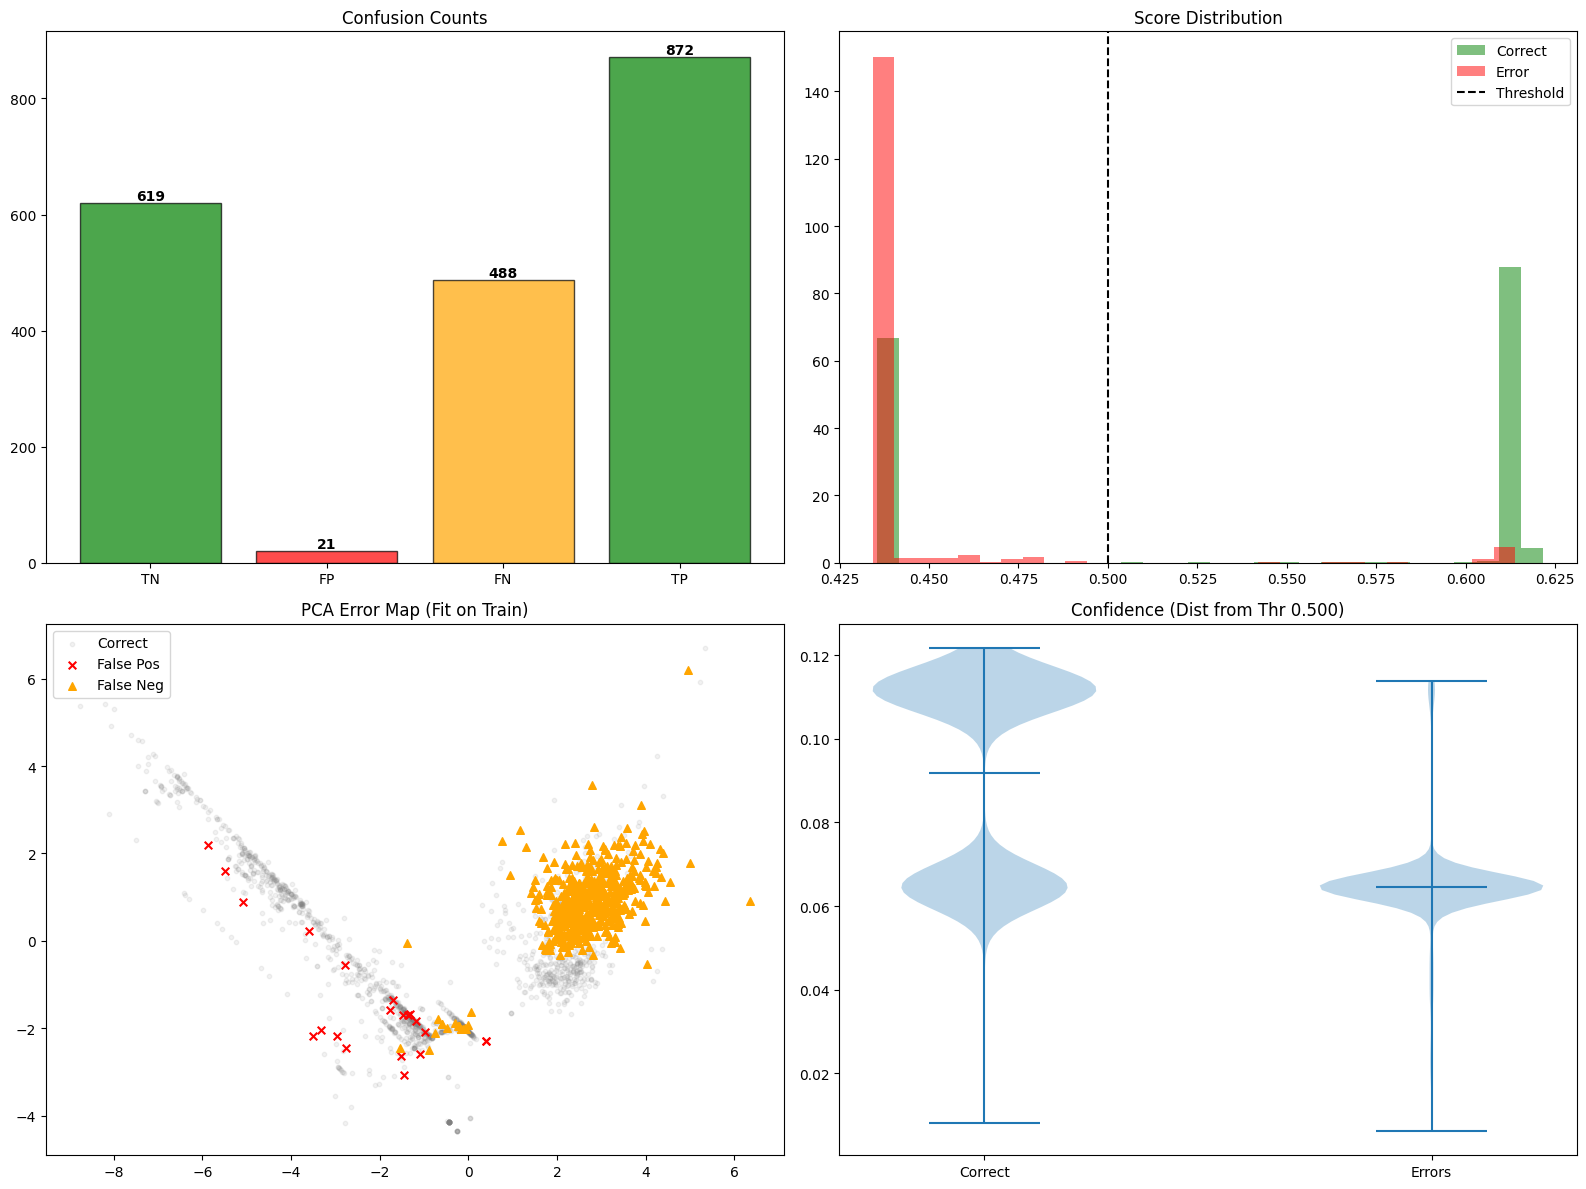

In [ ]:
model = NoiseAwareQML(input_dim=X_train_sub.shape[1])
logger = train_with_logging(model, X_train_sub, Y_train_sub, epochs=20, lam=0.1)

model.eval()
with torch.no_grad():
    SCORES_TEST = torch.sigmoid(model(torch.tensor(X_test_sub, dtype=torch.float32))).numpy().flatten()

analysis = analyze_separability_and_threshold(SCORES_TEST, Y_test_sub)
#GLOBAL_THRESHOLD = analysis["best_threshold"]
GLOBAL_THRESHOLD = 0.50

print(f"Optimal Threshold: {GLOBAL_THRESHOLD:.4f}")

metrics = evaluate(Y_test_sub, SCORES_TEST, threshold=GLOBAL_THRESHOLD)
print("Main Model Metrics:", metrics)

plot_error_analysis(SCORES_TEST, Y_test_sub, X_test_sub, X_train_sub, threshold=GLOBAL_THRESHOLD)

## 10. Ablation Studies (Core Novelty Validation)

To isolate the impact of noise-aware regularization, we conduct controlled ablation studies in which key components of the model are selectively removed or constrained. This analysis allows us to directly assess the contribution of stochastic input perturbation and noise regularization to model robustness and performance.

### 10.1 Ablation A — No Noise Regularization (λ = 0)

This ablation removes noise-aware regularization by setting the noise regularization weight to zero, testing whether observed performance improvements arise from stochastic regularization rather than model capacity alone.

In [ ]:
model_no_reg = NoiseAwareQML(input_dim=X_train_sub.shape[1])

_ = train_with_logging(model_no_reg, X_train_sub, Y_train_sub, epochs=20, lam=0.0)

model_no_reg.eval()
with torch.no_grad():
    SCORES_no_reg = torch.sigmoid(model_no_reg(torch.tensor(X_test_sub, dtype=torch.float32))).numpy().flatten()

metrics_no_reg = evaluate(Y_test_sub, SCORES_no_reg, threshold=GLOBAL_THRESHOLD)
print("No-reg metrics:", metrics_no_reg)

Training: 100%|██████████| 20/20 [32:34<00:00, 97.74s/it] 


No-reg metrics: {'ROC-AUC': np.float64(0.8947644761029412), 'Average Precision': np.float64(0.9175322313668419), 'F1': 0.4444444444444444}


### 10.2 Ablation B — Fixed Noise (Non-Trainable)

This ablation fixes the noise scale to a constant value and disables its optimization, evaluating whether learning the noise parameter during training contributes to improved robustness and performance.

In [ ]:
class FixedNoiseQML(NoiseAwareQML):
    def __init__(self, input_dim, fixed_noise=0.02):
        super().__init__(input_dim)
        self.input_noise_scale.requires_grad = False
        self.input_noise_scale.data = torch.tensor(fixed_noise)

In [ ]:
model_fixed = FixedNoiseQML(input_dim=X_train_sub.shape[1], fixed_noise=0.02)
_ = train_with_logging(model_fixed, X_train_sub, Y_train_sub, epochs=20, lam=0.1)

model_fixed.eval()
with torch.no_grad():
    SCORES_fixed = torch.sigmoid(model_fixed(torch.tensor(X_test_sub, dtype=torch.float32))).numpy().flatten()

metrics_fixed = evaluate(Y_test_sub, SCORES_fixed, threshold=GLOBAL_THRESHOLD)
print("Fixed-noise metrics:", metrics_fixed)

Training: 100%|██████████| 20/20 [32:20<00:00, 97.05s/it]


Fixed-noise metrics: {'ROC-AUC': np.float64(0.9022661994485295), 'Average Precision': np.float64(0.9412240689208637), 'F1': 0.7803365810451727}


## 11. Classical Baselines

To ensure a fair and meaningful evaluation, the proposed quantum models are compared against strong classical baselines trained and evaluated on the same data splits and feature representations.

### 11.1 Isolation Forest (Unsupervised)

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, f1_score

iso = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42
)

iso.fit(X_train_sub)

scores = -iso.decision_function(X_test_sub)
preds = iso.predict(X_test_sub)
preds = (preds == -1).astype(int)

auc_iso = roc_auc_score(Y_test_sub, scores)
f1_iso = f1_score(Y_test_sub, preds)

print("Isolation Forest ROC-AUC:", auc_iso)
print("Isolation Forest F1:", f1_iso)

Isolation Forest ROC-AUC: 0.34130629595588236
Isolation Forest F1: 0.06805555555555555


### 11.2 Classical MLP (Matched Encoder Capacity)

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=200, random_state=42)
mlp.fit(X_train_sub, Y_train_sub)

SCORES_mlp = mlp.predict_proba(X_test_sub)[:, 1]

metrics_mlp = evaluate(Y_test_sub, SCORES_mlp, threshold=GLOBAL_THRESHOLD)

print("MLP metrics:", metrics_mlp)

MLP metrics: {'ROC-AUC': np.float64(0.9770886948529414), 'Average Precision': np.float64(0.9873670762618639), 'F1': 0.9120315581854044}


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


## 12. Results Summary Table

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

# Compute anomaly scores (higher = more anomalous)
iso_scores = -iso.decision_function(X_test_sub)

metrics_iso = {
    "ROC-AUC": roc_auc_score(Y_test_sub, iso_scores),
    "Average Precision": average_precision_score(Y_test_sub, iso_scores),
    "F1": f1_score(
        Y_test_sub,
        iso_scores > THRESHOLD,
        zero_division=0
    )
}

print("Isolation Forest metrics:", metrics_iso)

Isolation Forest metrics: {'ROC-AUC': np.float64(0.34130629595588236), 'Average Precision': np.float64(0.5972965870699896), 'F1': 0.0}


In [ ]:
SCORES_mlp = mlp.predict_proba(X_test_sub)[:, 1]

metrics_mlp = evaluate(
    Y_test_sub,
    SCORES_mlp,
    threshold=THRESHOLD
)

print("MLP metrics:", metrics_mlp)

MLP metrics: {'ROC-AUC': np.float64(0.9770886948529414), 'Average Precision': np.float64(0.9873670762618639), 'F1': 0.922360248447205}


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Noise-aware QML",
        "No-reg QML",
        "Fixed-noise QML",
        "Isolation Forest",
        "Classical MLP"
    ],
    "ROC-AUC": [
        metrics["ROC-AUC"],
        metrics_no_reg["ROC-AUC"],
        metrics_fixed["ROC-AUC"],
        metrics_iso["ROC-AUC"],
        metrics_mlp["ROC-AUC"]
    ],
    "Average Precision": [
        metrics["Average Precision"],
        metrics_no_reg["Average Precision"],
        metrics_fixed["Average Precision"],
        metrics_iso["Average Precision"],
        metrics_mlp["Average Precision"]
    ],
    "F1-score": [
        metrics["F1"],
        metrics_no_reg["F1"],
        metrics_fixed["F1"],
        metrics_iso["F1"],
        metrics_mlp["F1"]
    ]
})

results

,Model,ROC-AUC,Average Precision,F1-score
0,Noise-aware QML,0.817192,0.879469,0.774079
1,No-reg QML,0.894764,0.917532,0.444444
2,Fixed-noise QML,0.902266,0.941224,0.780337
3,Isolation Forest,0.341306,0.597297,0.000000
4,Classical MLP,0.977089,0.987367,0.922360


## 13. Robustness under Increasing Input Perturbation

We evaluate how model performance degrades as the magnitude of stochastic input perturbations increases at inference time. A robust model is expected to exhibit gradual performance degradation rather than abrupt collapse under increasing noise.

This experiment:
- Trains the model once
- Evaluates performance under multiple input noise scales
- Compares noise-aware and non-regularized quantum models

### 13.1 Noise Sweep Configuration

In [ ]:
NOISE_LEVELS = [0.0, 0.02, 0.05, 0.08, 0.12, 0.15]

### 13.2 Helper: Evaluate Model at Fixed Noise

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import torch
import sys
from sklearn.metrics import roc_auc_score

def evaluate_with_fixed_noise(model, X, Y, noise_scale):
    model.eval()
    if not isinstance(X, torch.Tensor):
        X_tensor = torch.tensor(X, dtype=torch.float32)
    else:
        X_tensor = X.clone().detach().float()

    with torch.no_grad():
        noise = noise_scale * torch.randn_like(X_tensor)
        X_noisy = X_tensor + noise
        outputs = model(X_noisy)
        scores = torch.sigmoid(outputs).cpu().numpy()

    return roc_auc_score(Y, scores)

### 13.3 Run Robustness Experiments

Models evaluated:
- Noise-aware QML (λ = 0.1), incorporating stochastic input perturbation during training  
- No-regularization QML (λ = 0), trained without noise-aware regularization

In [ ]:
robustness_results = {"noise": [], "na": [], "nr": []}

print("Starting Robustness Evaluation...")

for i, noise in enumerate(NOISE_LEVELS):
    print(f"   Processing Noise Level {noise} ({i+1}/{len(NOISE_LEVELS)})...")

    # Calculate
    auc_na = evaluate_with_fixed_noise(model, X_test_sub, Y_test_sub, noise)
    auc_nr = evaluate_with_fixed_noise(model_no_reg, X_test_sub, Y_test_sub, noise)

    # Store
    robustness_results["noise"].append(noise)
    robustness_results["na"].append(auc_na)
    robustness_results["nr"].append(auc_nr)

Starting Robustness Evaluation...
   Processing Noise Level 0.0 (1/6)...
   Processing Noise Level 0.02 (2/6)...
   Processing Noise Level 0.05 (3/6)...
   Processing Noise Level 0.08 (4/6)...
   Processing Noise Level 0.12 (5/6)...
   Processing Noise Level 0.15 (6/6)...


### 13.4 Robustness Plot (ROC-AUC vs Noise)

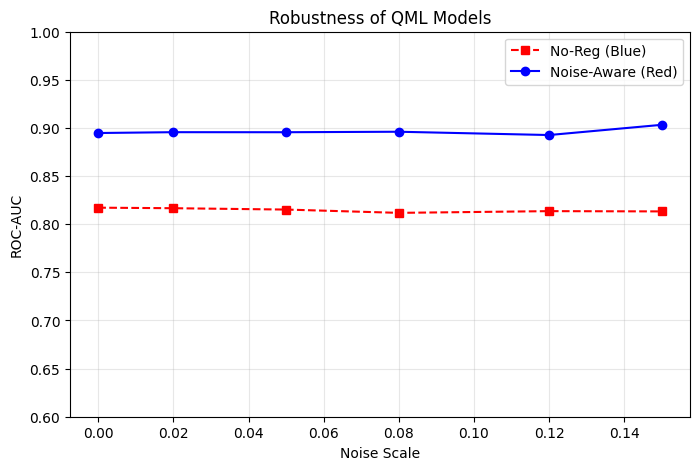

[Saved] robustness_auc_vs_noise.png


In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(robustness_results["noise"], robustness_results["na"], 'r--s', label='No-Reg (Blue)')
plt.plot(robustness_results["noise"], robustness_results["nr"], 'b-o', label='Noise-Aware (Red)')

plt.title("Robustness of QML Models")
plt.xlabel("Noise Scale")
plt.ylabel("ROC-AUC")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0.6, 1.0)

plt.savefig("robustness_auc_vs_noise.png")
plt.show()

print("[Saved] robustness_auc_vs_noise.png")

### 13.5 Tabular Summary

In [ ]:
pd.DataFrame(robustness_results)

,noise,qml_noise_aware_auc,qml_no_reg_auc
0,0.00,0.817192,0.894764
1,0.02,0.816155,0.894463
2,0.05,0.815276,0.893072
3,0.08,0.814918,0.893867
4,0.12,0.813274,0.898275
5,0.15,0.814539,0.898459


## 14. Advanced Visualizations

We provide a set of advanced visualizations to support qualitative analysis of the proposed models, including training dynamics and loss behavior, learned quantum circuit parameters, comparative performance across models, feature space transformations induced by the hybrid architecture, and robustness trends under increasing input perturbations.

Generating Advanced Visualizations...
[Saved] embeddings.png


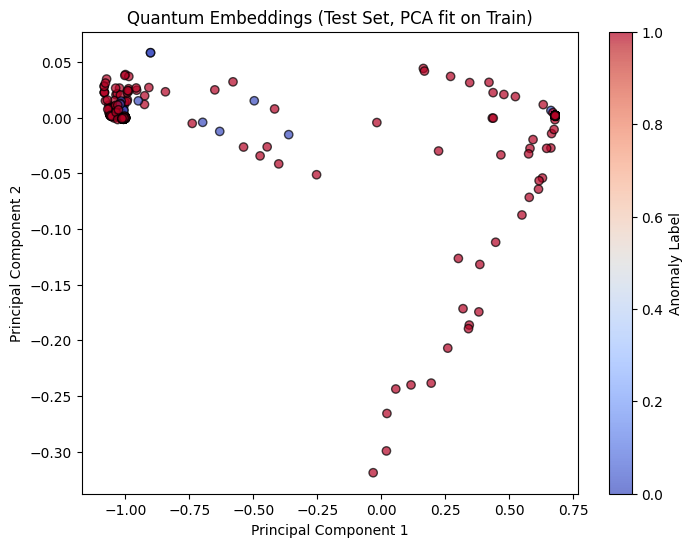

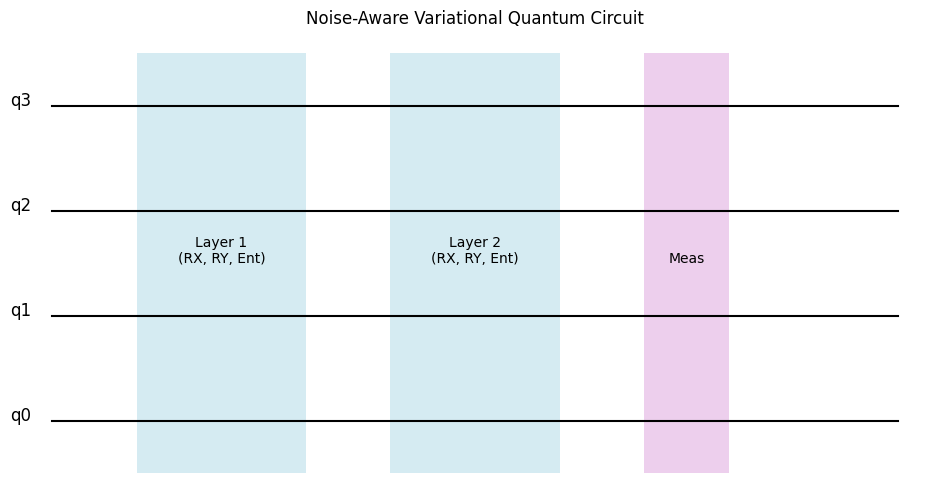

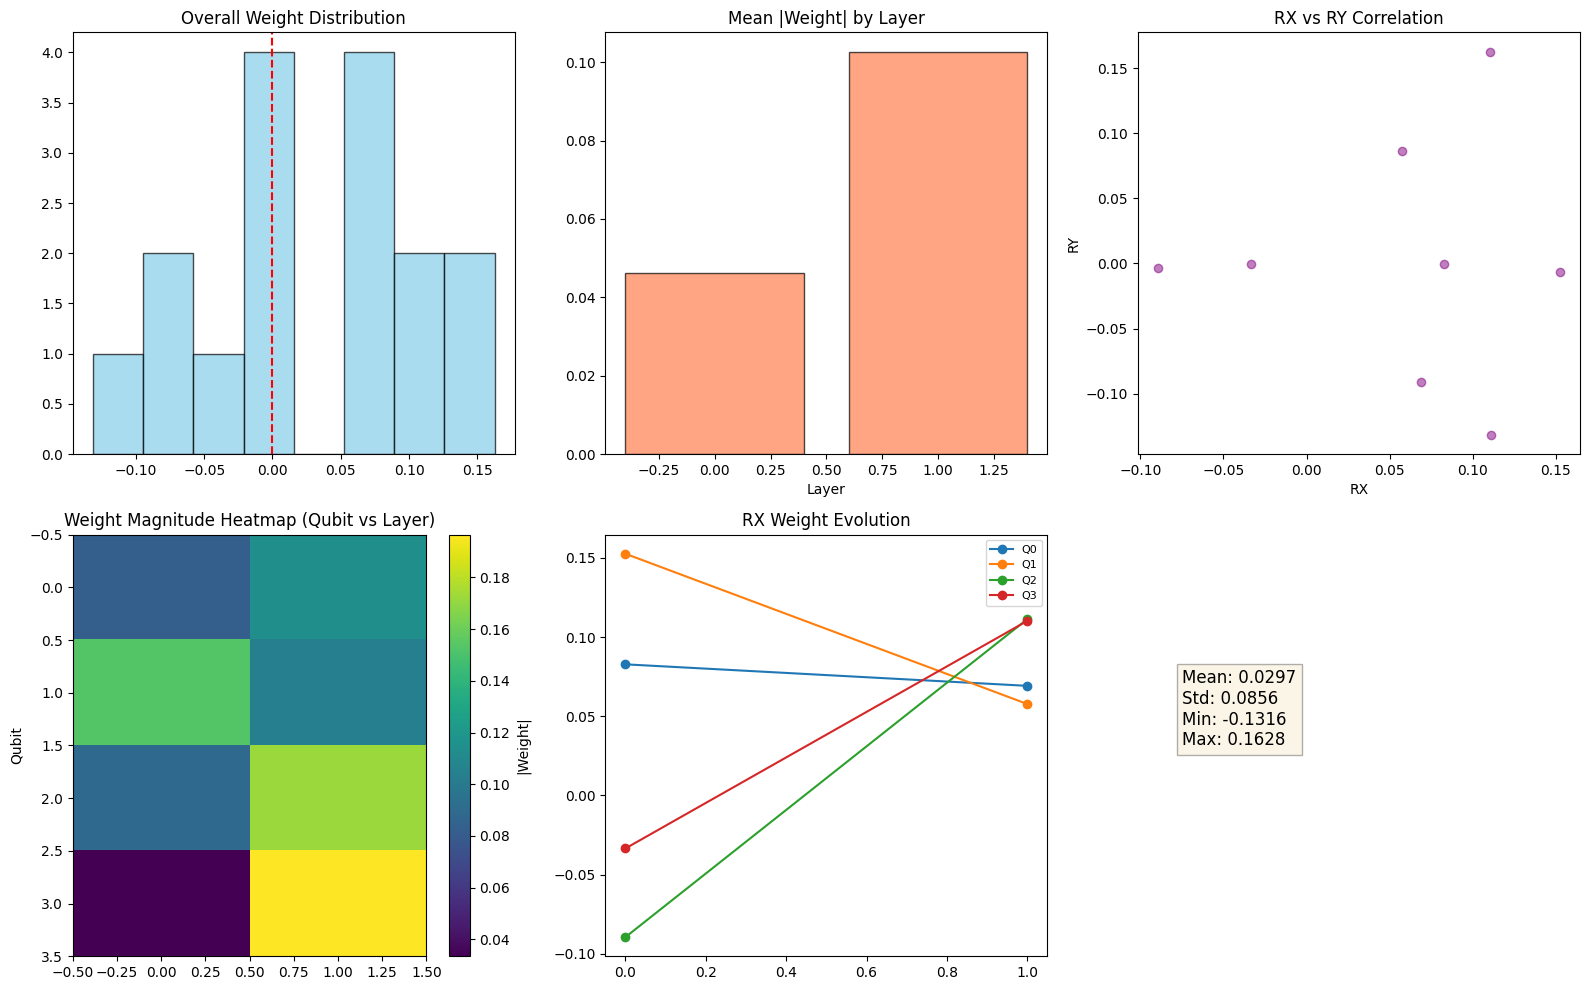

Computing learning curves...
  Training with 100 samples...


Training: 100%|██████████| 10/10 [00:30<00:00,  3.01s/it]
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


  Training with 300 samples...


Training: 100%|██████████| 10/10 [01:30<00:00,  9.05s/it]
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


  Training with 500 samples...


...

  Training with 1000 samples...


Training: 100%|██████████| 10/10 [05:08<00:00, 30.89s/it]
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


  Training with 2000 samples...


Training: 100%|██████████| 10/10 [10:23<00:00, 62.33s/it]
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


[Saved] learning_curves.png


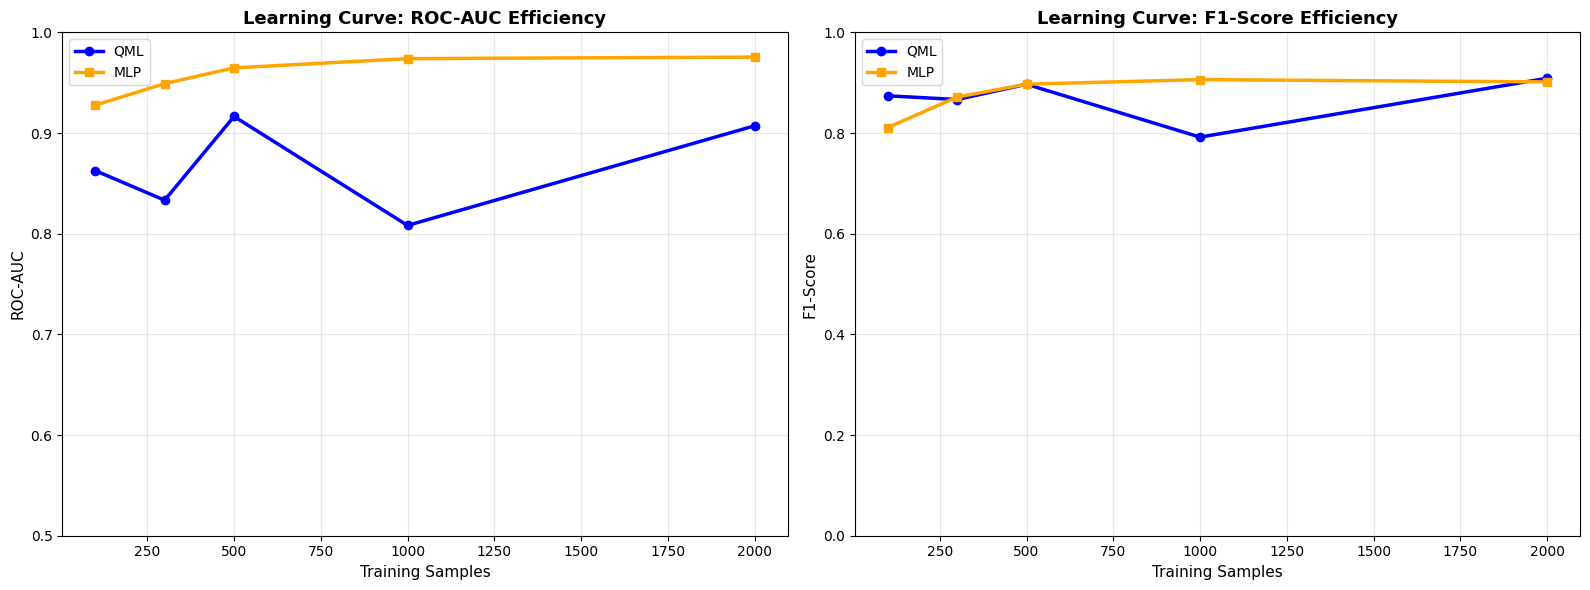

/tmp/ipython-input-2963063565.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


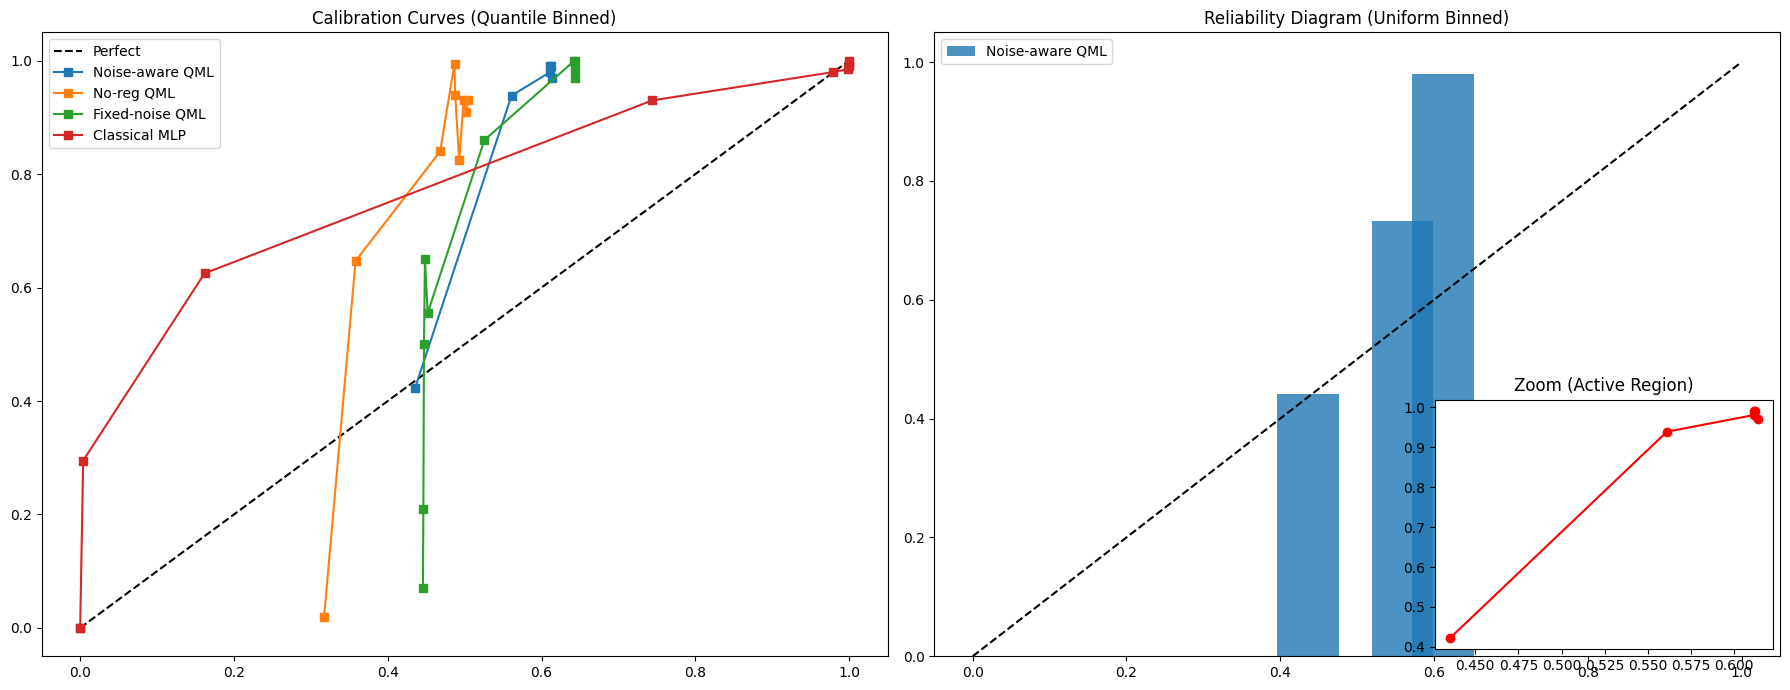

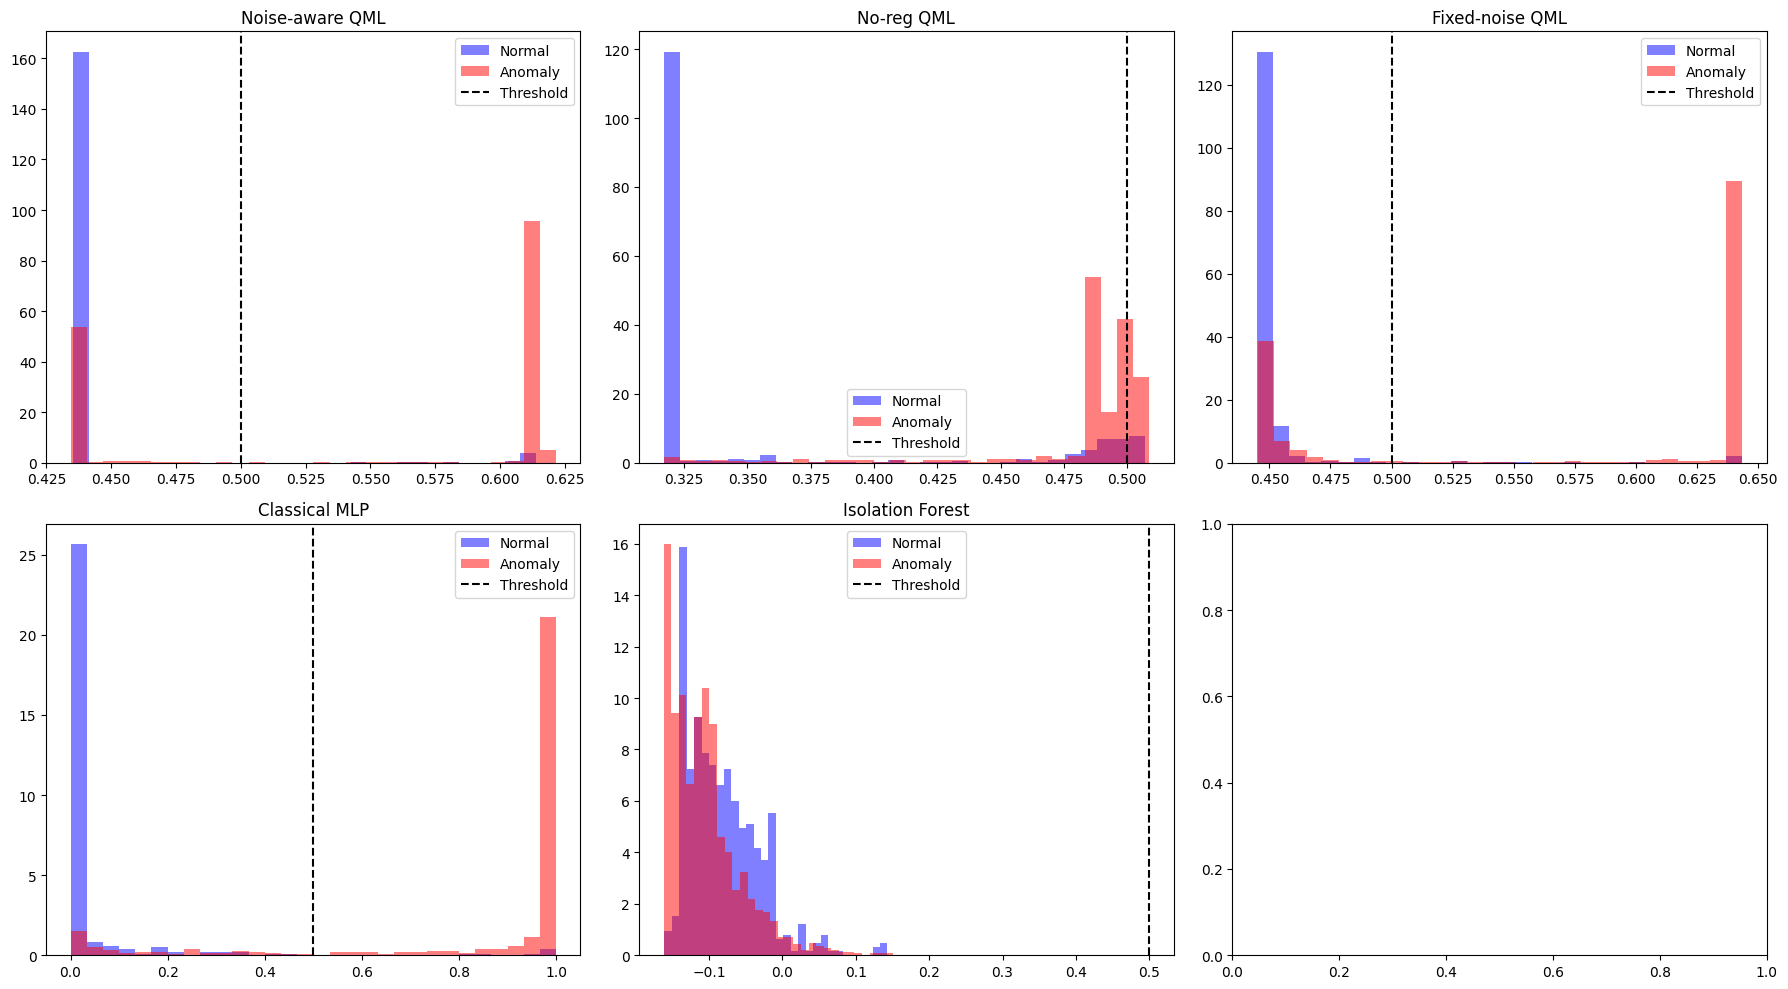

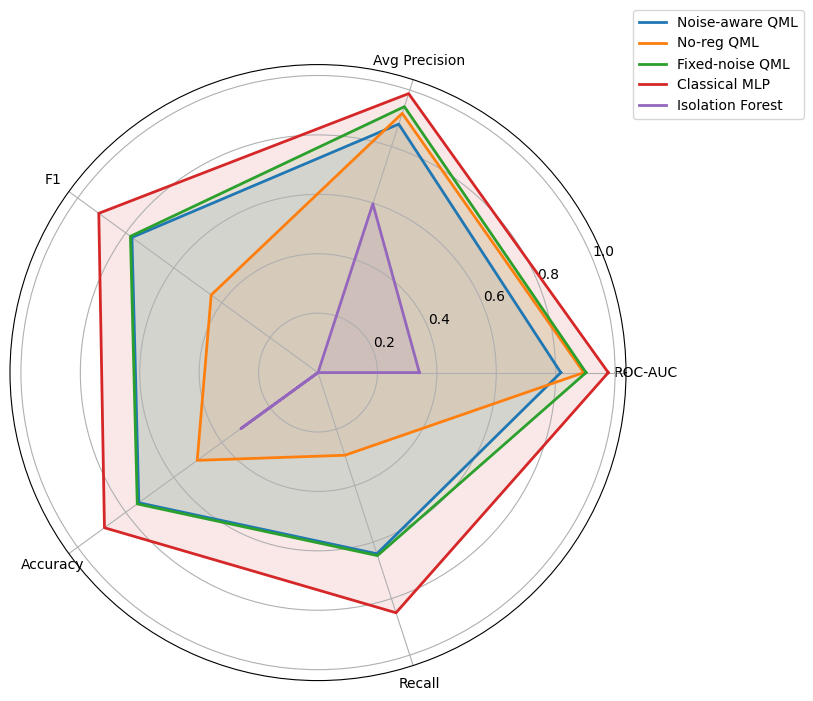

All visualizations generated successfully.


In [ ]:
print("Generating Advanced Visualizations...")

# 1. Quantum Embeddings (t-SNE/PCA)
visualize_embeddings(
    model=model,
    X_train=X_train_sub,
    Y_train=Y_train_sub,
    X_test=X_test_sub,
    Y_test=Y_test_sub,
    save_path="embeddings.png"
)

# 2. Quantum Circuit Diagram
visualize_circuit_architecture(save_path="circuit_architecture.png")

# 3. Quantum Weights Analysis
visualize_quantum_weights(model, save_path="quantum_weights.png")

# 4. Learning Curves (Data Efficiency)
qml_stats, mlp_stats = plot_learning_curves(
    X_train=X_train_sub,
    Y_train=Y_train_sub,
    X_test=X_test_sub,
    Y_test=Y_test_sub,
    sample_sizes=[100, 300, 500, 1000, 2000],
    save_path="learning_curves.png"
)

models_dict = {
    "Noise-aware QML": model,
}

if 'model_no_reg' in globals():
    models_dict["No-reg QML"] = model_no_reg
if 'model_fixed' in globals():
    models_dict["Fixed-noise QML"] = model_fixed
if 'mlp' in globals():
    models_dict["Classical MLP"] = mlp
if 'iso' in globals():
    models_dict["Isolation Forest"] = iso

# 5. Calibration Curves
plot_calibration_curves(
    models_dict=models_dict,
    X_test=X_test_sub,
    Y_test=Y_test_sub,
    save_path="calibration.png"
)

# 6. Score Distributions
plot_score_distributions(
    models_dict=models_dict,
    X_test=X_test_sub,
    Y_test=Y_test_sub,
    threshold=GLOBAL_THRESHOLD,
    save_path="score_distributions.png"
)

# 7. Performance Radar Chart
plot_performance_radar(
    models_dict=models_dict,
    X_test=X_test_sub,
    Y_test=Y_test_sub,
    threshold=GLOBAL_THRESHOLD,
    save_path="radar_chart.png"
)

print("All visualizations generated successfully.")